# 02 - Preprocessing Check - Jena Climate (Seq2Seq Weather Forecasting)

This notebook proves that `src/data/preprocessing.py` turns the raw 10-minute
Jena Climate CSV into a clean, leakage-safe, model-ready dataset. It only
**calls** the pipeline and inspects its output - all preprocessing logic
lives in the module, not here. No model is trained in this notebook.

Pipeline: Raw CSV -> Data Cleaning -> Hourly Resampling -> Feature
Engineering -> Temporal Split -> Missing Handling -> Scaling -> Processed
Dataset (sliding-window sampling is a later step).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import src.data.preprocessing as pp

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "jena_climate_2009_2016.csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
print("Project root:", PROJECT_ROOT)
print("Raw path exists:", RAW_PATH.exists())

Project root: E:\Project_Deep\Project_DL_Weather_Forecasting
Raw path exists: True


## 1. Load raw data

In [2]:
raw_df = pp.load_raw_data(RAW_PATH)
raw_rows, raw_cols = raw_df.shape
print(f"Raw rows: {raw_rows:,}  |  Raw columns: {raw_cols}")
raw_df.head()

INFO Loaded 420551 raw rows, 15 columns from E:\Project_Deep\Project_DL_Weather_Forecasting\data\raw\jena_climate_2009_2016.csv


Raw rows: 420,551  |  Raw columns: 15


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
raw_diffs = raw_df[pp.TIMESTAMP_COLUMN].sort_values().diff().dropna()
raw_mode_minutes = raw_diffs.mode().iloc[0].total_seconds() / 60
print(f"Raw sampling frequency (mode): {raw_mode_minutes:.0f} minutes")
print(f"Raw timestamp sorted in file: {raw_df[pp.TIMESTAMP_COLUMN].is_monotonic_increasing}")
print(f"Raw duplicate timestamps: {raw_df[pp.TIMESTAMP_COLUMN].duplicated().sum()}")

Raw sampling frequency (mode): 10 minutes
Raw timestamp sorted in file: False
Raw duplicate timestamps: 327


## 2. Run the preprocessing pipeline

In [4]:
output_path = pp.preprocess(RAW_PATH, OUTPUT_DIR)
print("Processed artifacts written to:", output_path)
list(sorted(p.name for p in OUTPUT_DIR.iterdir()))

INFO Loaded 420551 raw rows, 15 columns from E:\Project_Deep\Project_DL_Weather_Forecasting\data\raw\jena_climate_2009_2016.csv


INFO Timestamp cleaning: 420551 -> 420224 rows (dropped 327 exact duplicates, aggregated 0 conflicting groups)


INFO Resampled to hourly: 70129 rows spanning 2009-01-01 00:00:00 to 2017-01-01 00:00:00


INFO Temporal split: train=49090 val=10519 test=10520 rows (train ends 2014-08-08T09:00:00, val ends 2015-10-20T16:00:00)


INFO Missing-value handling done. Remaining input NaNs: train=0 val=0 test=0. Target left unimputed with NaNs: train=0 val=15 test=73


...

INFO Wrote E:\Project_Deep\Project_DL_Weather_Forecasting\data\processed\split_metadata.json


INFO Wrote E:\Project_Deep\Project_DL_Weather_Forecasting\data\processed\feature_schema.json


INFO Preprocessing complete: train=49090 val=10519 test=10520 rows, 32 features -> E:\Project_Deep\Project_DL_Weather_Forecasting\data\processed


Processed artifacts written to: E:\Project_Deep\Project_DL_Weather_Forecasting\data\processed


['.gitkeep',
 'feature_schema.json',
 'scaler.joblib',
 'split_metadata.json',
 'test_processed.csv',
 'train_processed.csv',
 'val_processed.csv']

## 3. Before vs after comparison

In [5]:
train_df = pd.read_csv(OUTPUT_DIR / "train_processed.csv", parse_dates=[pp.TIMESTAMP_COLUMN])
val_df = pd.read_csv(OUTPUT_DIR / "val_processed.csv", parse_dates=[pp.TIMESTAMP_COLUMN])
test_df = pd.read_csv(OUTPUT_DIR / "test_processed.csv", parse_dates=[pp.TIMESTAMP_COLUMN])
processed_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

comparison = pd.DataFrame(
    {
        "raw": {
            "rows": raw_rows,
            "features": raw_cols - 1,  # excluding timestamp
            "sampling_frequency": f"{raw_mode_minutes:.0f} min",
        },
        "processed (train+val+test)": {
            "rows": len(processed_df),
            "features": len(pp.FEATURE_COLUMNS),
            "sampling_frequency": "60 min",
        },
    }
)
comparison

,raw,processed (train+val+test)
rows,420551,70129
features,14,32
sampling_frequency,10 min,60 min


In [6]:
print(f"train rows: {len(train_df):,}")
print(f"val rows:   {len(val_df):,}")
print(f"test rows:  {len(test_df):,}")
print(f"sum:        {len(train_df) + len(val_df) + len(test_df):,}  (should equal processed rows above)")

train rows: 49,090
val rows:   10,519
test rows:  10,520
sum:        70,129  (should equal processed rows above)


## 4. Timestamp checks

In [7]:
is_sorted = processed_df[pp.TIMESTAMP_COLUMN].is_monotonic_increasing
diffs = processed_df[pp.TIMESTAMP_COLUMN].diff().dropna()
is_hourly = (diffs == pd.Timedelta("1h")).all()

print(f"Combined train+val+test sorted ascending: {is_sorted}")
print(f"Every consecutive step is exactly 1 hour: {is_hourly}")
print(f"Unique step sizes found: {diffs.unique()}")

assert is_sorted, "Processed timestamps are not sorted"
assert is_hourly, "Processed timestamps are not on a regular hourly grid"
print("OK: timestamps are sorted and strictly hourly, even across the raw data's gap periods.")

Combined train+val+test sorted ascending: True
Every consecutive step is exactly 1 hour: True
Unique step sizes found: <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[ns]
OK: timestamps are sorted and strictly hourly, even across the raw data's gap periods.


## 5. Missing value checks

In [8]:
with open(PROJECT_ROOT / "artifacts" / "preprocessing" / "split_metadata.json") as f:
    import json
    split_metadata = json.load(f)

missing_summary = pd.DataFrame(
    {
        "input_features_NaN": split_metadata["missing_handling"]["remaining_missing_after_fill"],
        "target_T_degC_NaN": split_metadata["missing_handling"]["remaining_missing_target"],
    }
)
missing_summary

,input_features_NaN,target_T_degC_NaN
train,0,0
validation,0,15
test,0,73


In [9]:
print("Input features: 0 NaN expected in every split (forward-fill + train median close every gap).")
print("Target T (degC): NaN is EXPECTED where the raw data had a real gap - it is intentionally")
print("left unimputed; a later sliding-window step must drop windows overlapping these timestamps")
print("(missing_T_degC marks exactly where).")
assert (train_df[pp.FEATURE_COLUMNS].drop(columns=[pp.TARGET_COLUMN]).isna().sum() == 0).all()
assert (val_df[pp.FEATURE_COLUMNS].drop(columns=[pp.TARGET_COLUMN]).isna().sum() == 0).all()
assert (test_df[pp.FEATURE_COLUMNS].drop(columns=[pp.TARGET_COLUMN]).isna().sum() == 0).all()
print("OK: no NaNs remain in any input feature.")

Input features: 0 NaN expected in every split (forward-fill + train median close every gap).
Target T (degC): NaN is EXPECTED where the raw data had a real gap - it is intentionally
left unimputed; a later sliding-window step must drop windows overlapping these timestamps
(missing_T_degC marks exactly where).
OK: no NaNs remain in any input feature.


## 6. Scaling checks

In [10]:
train_means = train_df[pp.FEATURE_COLUMNS].mean()
train_stds = train_df[pp.FEATURE_COLUMNS].std()

print(f"max |train mean| across features: {train_means.abs().max():.2e}  (expect ~0)")
print(f"max |train std - 1| across non-constant features: "
      f"{(train_stds[train_stds > 0] - 1).abs().max():.2e}  (expect ~0)")

constant_in_train = train_stds[train_stds == 0].index.tolist()
print(f"\nFeatures with zero variance in train ({len(constant_in_train)}): {constant_in_train}")
print("These are missing_* indicators for gaps that happen not to fall inside the train window -")
print("they are constant 0 in train by construction, so their scaled std is 0, not 1; that is")
print("expected for a rare-event flag, not a bug. They still vary correctly in val/test below.")

max |train mean| across features: 1.53e-08  (expect ~0)
max |train std - 1| across non-constant features: 1.02e-05  (expect ~0)

Features with zero variance in train (14): ['missing_p_mbar', 'missing_T_degC', 'missing_Tpot_K', 'missing_Tdew_degC', 'missing_rh_pct', 'missing_VPmax_mbar', 'missing_VPact_mbar', 'missing_VPdef_mbar', 'missing_sh_gkg', 'missing_H2OC_mmolmol', 'missing_rho_gm3', 'missing_wv_ms', 'missing_max_wv_ms', 'missing_wd_deg']
These are missing_* indicators for gaps that happen not to fall inside the train window -
they are constant 0 in train by construction, so their scaled std is 0, not 1; that is
expected for a rare-event flag, not a bug. They still vary correctly in val/test below.


In [11]:
if constant_in_train:
    activity = pd.DataFrame(
        {
            "val_rows_flagged": (val_df[constant_in_train] > 0).sum(),
            "test_rows_flagged": (test_df[constant_in_train] > 0).sum(),
        }
    )
    display(activity)
else:
    print("No constant-in-train indicators.")

,val_rows_flagged,test_rows_flagged
missing_p_mbar,15,73
missing_T_degC,15,73
missing_Tpot_K,15,73
missing_Tdew_degC,15,73
missing_rh_pct,15,73
missing_VPmax_mbar,15,73
missing_VPact_mbar,15,73
missing_VPdef_mbar,15,73
missing_sh_gkg,15,73
missing_H2OC_mmolmol,15,73


## 7. Leakage checks

In [12]:
train_start = pd.Timestamp(split_metadata["train"]["start"])
train_end = pd.Timestamp(split_metadata["train"]["end"])
val_start = pd.Timestamp(split_metadata["validation"]["start"])
val_end = pd.Timestamp(split_metadata["validation"]["end"])
test_start = pd.Timestamp(split_metadata["test"]["start"])
test_end = pd.Timestamp(split_metadata["test"]["end"])

print(f"train: {train_start} -> {train_end}")
print(f"val:   {val_start} -> {val_end}")
print(f"test:  {test_start} -> {test_end}")

assert train_end < val_start, "train/validation overlap!"
assert val_end < test_start, "validation/test overlap!"
print("OK: train < validation < test with no overlap (chronological split).")

train: 2009-01-01 00:00:00 -> 2014-08-08 09:00:00
val:   2014-08-08 10:00:00 -> 2015-10-20 16:00:00
test:  2015-10-20 17:00:00 -> 2017-01-01 00:00:00
OK: train < validation < test with no overlap (chronological split).


In [13]:
# Re-derive the pre-scaling train/val/test frames independently (bypassing preprocess())
# to prove the shipped scaler.joblib was fit on the TRAIN split only.
clean_df, _ = pp.clean_timestamps(raw_df)
hourly_df = pp.add_missing_indicators(pp.add_time_features(pp.resample_hourly(clean_df)))
train_raw, val_raw, test_raw, _ = pp.temporal_split(hourly_df)
train_imp, val_imp, test_imp, _ = pp.impute_missing(train_raw, val_raw, test_raw)

scaler = joblib.load(PROJECT_ROOT / "artifacts" / "preprocessing" / "scaler.joblib")
recomputed_train_mean = train_imp[pp.FEATURE_COLUMNS].mean().to_numpy()
recomputed_train_std = train_imp[pp.FEATURE_COLUMNS].std(ddof=0).to_numpy()

print("scaler.mean_ matches independently-recomputed TRAIN-only mean:",
      np.allclose(scaler.mean_, recomputed_train_mean, atol=1e-3, equal_nan=True))
print("scaler.scale_ matches independently-recomputed TRAIN-only std:",
      np.allclose(scaler.scale_, np.where(recomputed_train_std == 0, 1.0, recomputed_train_std), atol=1e-3))

INFO Timestamp cleaning: 420551 -> 420224 rows (dropped 327 exact duplicates, aggregated 0 conflicting groups)


INFO Resampled to hourly: 70129 rows spanning 2009-01-01 00:00:00 to 2017-01-01 00:00:00


INFO Temporal split: train=49090 val=10519 test=10520 rows (train ends 2014-08-08T09:00:00, val ends 2015-10-20T16:00:00)


INFO Missing-value handling done. Remaining input NaNs: train=0 val=0 test=0. Target left unimputed with NaNs: train=0 val=15 test=73


scaler.mean_ matches independently-recomputed TRAIN-only mean: True
scaler.scale_ matches independently-recomputed TRAIN-only std: True


In [14]:
# Contrast with the leaked alternative: fitting on everything shifts the statistics.
from sklearn.preprocessing import StandardScaler

leaked_scaler = StandardScaler().fit(pd.concat([train_imp, val_imp, test_imp])[pp.FEATURE_COLUMNS])
mean_shift = np.nanmax(np.abs(leaked_scaler.mean_ - scaler.mean_))
print(f"Max shift between train-only mean and (train+val+test)-fit mean: {mean_shift:.4f}")
print("Non-zero shift confirms fitting on the full dataset would have leaked val/test")
print("statistics into normalization - which this pipeline avoids by fitting on train only.")

Max shift between train-only mean and (train+val+test)-fit mean: 1.1808
Non-zero shift confirms fitting on the full dataset would have leaked val/test
statistics into normalization - which this pipeline avoids by fitting on train only.


## 8. Processed temperature plot

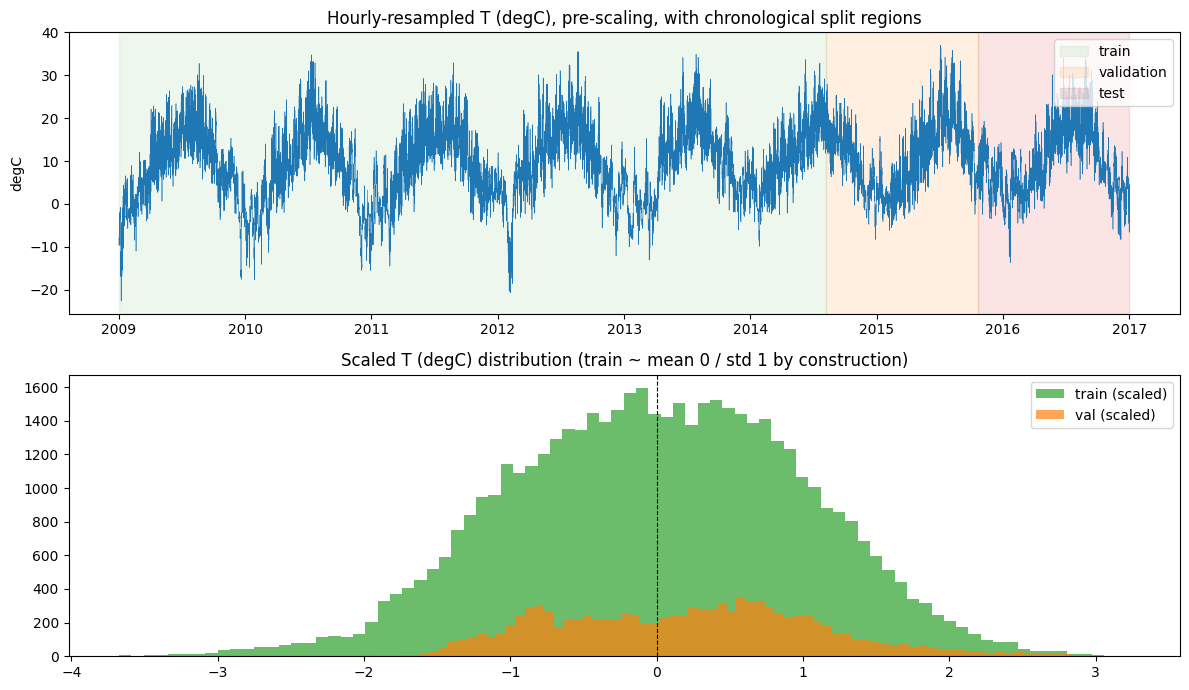

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

axes[0].plot(hourly_df[pp.TIMESTAMP_COLUMN], hourly_df[pp.TARGET_COLUMN], linewidth=0.4, color="tab:blue")
axes[0].axvspan(train_start, train_end, color="tab:green", alpha=0.08, label="train")
axes[0].axvspan(val_start, val_end, color="tab:orange", alpha=0.12, label="validation")
axes[0].axvspan(test_start, test_end, color="tab:red", alpha=0.12, label="test")
axes[0].set_title("Hourly-resampled T (degC), pre-scaling, with chronological split regions")
axes[0].set_ylabel("degC")
axes[0].legend(loc="upper right")

axes[1].hist(train_df[pp.TARGET_COLUMN].dropna(), bins=80, color="tab:green", alpha=0.7, label="train (scaled)")
axes[1].hist(val_df[pp.TARGET_COLUMN].dropna(), bins=80, color="tab:orange", alpha=0.7, label="val (scaled)")
axes[1].set_title("Scaled T (degC) distribution (train ~ mean 0 / std 1 by construction)")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].legend()

fig.tight_layout()
plt.show()

## 9. Processed feature sample

In [16]:
train_df[[pp.TIMESTAMP_COLUMN] + pp.FEATURE_COLUMNS[:8]].head(10)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar)
0,2009-01-01 00:00:00,0.948907,-2.014297,-2.074466,-1.968587,1.083659,-1.314739,-1.497932,-0.790657
1,2009-01-01 01:00:00,0.948545,-1.986651,-2.046505,-1.931547,1.092974,-1.306490,-1.482811,-0.790727
2,2009-01-01 02:00:00,0.975079,-2.067430,-2.128743,-2.038843,1.068674,-1.329717,-1.525958,-0.790727
3,2009-01-01 03:00:00,1.004227,-2.082853,-2.146338,-2.064173,1.048423,-1.334058,-1.535854,-0.788987
4,2009-01-01 04:00:00,1.024931,-2.135099,-2.199698,-2.144227,0.998809,-1.348385,-1.565146,-0.784464
5,2009-01-01 05:00:00,1.067346,-2.177706,-2.245215,-2.196561,0.998809,-1.359673,-1.584147,-0.786204
6,2009-01-01 06:00:00,1.121018,-2.129315,-2.201036,-2.134908,1.004884,-1.346432,-1.562375,-0.785856
7,2009-01-01 07:00:00,1.209063,-2.041981,-2.120519,-2.017097,1.039310,-1.322553,-1.516853,-0.786899
8,2009-01-01 08:00:00,1.292486,-1.970649,-2.055876,-1.937760,1.012985,-1.302148,-1.485582,-0.780984
9,2009-01-01 09:00:00,1.351786,-1.909535,-1.999648,-1.879213,0.962358,-1.283697,-1.461435,-0.772634


In [17]:
train_df[[pp.TIMESTAMP_COLUMN] + [c for c in pp.FEATURE_COLUMNS if c.startswith("missing_")][:6]].head(3)

,Date Time,missing_p_mbar,missing_T_degC,missing_Tpot_K,missing_Tdew_degC,missing_rh_pct,missing_VPmax_mbar
0,2009-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0
1,2009-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0
2,2009-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0


## Summary

- Raw 10-minute data (420,551 rows, 14 numeric columns) is cleaned, resampled
  to a strictly regular hourly grid, enriched with cyclical time features and
  missingness indicators, split chronologically 70/15/15, imputed without
  crossing the train/val/test boundary, and scaled with a scaler fit on train
  only.
- The processed dataset (32 features, target `T (degC)` at index
  1) matches the locked contract in
  `artifacts/preprocessing/feature_schema.json` and is ready for the next
  step: building 168-hour-in / 72-hour-out sliding windows.